# 4.2 Universal Functions (ufunc)

ufnc performs element-wise operations on data in arrays. 

Some examples of ufuncs that operate element-wise on arrays include:
- unicary functions:
 abs, fabs, sqrt, square, exp, log, log10, log2, 
 log1p (log(1+x)), 
 sign, ceil, floor, rint, modf,
 isnan (return boolean array if the value is NaN), 
 isfinite, isinf,
 cos, cosh, sin, sinh, tan, tanh, arccos, arccosh, arcsin, arcsinh, arctan, arctanh, 
 logical_not (compute the truth value of not x element-wise)

- binary functions:
 add, subtract, multiply, divide, 
 floor_divide (truncating the remainder), 
 power, maximum, minimum, 
 fmax, fmin (ignore NaN values),
 mod, copysign, greater, greater_equal, less, less_equal, equal, not_equal, logical_and, logical_or, logical_xor

In [2]:
import numpy as np

arr = np.arange(10)

In [ ]:
# examples of ufuncs that operate element-wise on arrays:

print(np.sqrt(arr)) # square root of each element in the array
print(np.exp(arr)) # exponential of each element in the array
print(np.add(arr, arr)) # add the array to itself
print(np.maximum(arr, arr**2)) # element-wise maximum of two arrays entriwise.

[0.         1.         1.41421356 1.73205081 2.         2.23606798
 2.44948974 2.64575131 2.82842712 3.        ]
[1.00000000e+00 2.71828183e+00 7.38905610e+00 2.00855369e+01
 5.45981500e+01 1.48413159e+02 4.03428793e+02 1.09663316e+03
 2.98095799e+03 8.10308393e+03]
[ 0  2  4  6  8 10 12 14 16 18]
[ 0  1  4  9 16 25 36 49 64 81]


In [ ]:
# examples of ufuncs that return multiple arrays:
arr = np.random.randn(7) * 5 # generate an array of 7 random numbers from a normal distribution, scaled by 5
print(arr)
print(np.modf(arr)) # return the fractional and integral parts of the array as separate arrays

remainder, whole_part = np.modf(arr) # unpack the result of np.modf into two separate variables

[-1.75807442  3.44195833  5.39208802  1.23050523 -0.1365468  -6.25220272
  0.15345586]
(array([-0.75807442,  0.44195833,  0.39208802,  0.23050523, -0.1365468 ,
       -0.25220272,  0.15345586]), array([-1.,  3.,  5.,  1., -0., -6.,  0.]))


# 4.3 Array-Oriented Programming with Arrays
## Replace writing loops with array expressions.
 - `np.meshgrid` can be used to evaluate functions on a 2D grid.
    Example: evaluating a function on a regular grid.

 - `np.where` is a vectorized version of the ternary expression x if condition else y.

- mathematical and statistical methods are available as ufuncs, such as:
    - `np.sum`, `np.prod`, `np.cumsum`, `np.cumprod`
    - `np.mean`, `np.std`, `np.var`, `np.min`, `np.max`, `np.argmin`, `np.argmax`

- methods for boolean arrays:
    - `any` and `all` can be used to check if any or all of the values in an array are true, respectively.
    - `sum` can be used to count the number of true values in a boolean array. e.g. `np.sum((x > 0) & (x < 10))` counts the number of values in x that are greater than 0 and less than 10.

- sorting:
    - `arr.sort()` returns a sorted copy of an array sorting from small to large. multi-dimensional arrays can be sorted along an axis. e.g. `arr.sort(1)` sorts each row of a 2D array in-place.
    - `np.sort` returns a sorted copy of an array, leaving the original array unchanged.

- `np.unique` in np vs. `set()` in python default: finds the unique values in an array and can also return the indices of the unique values and the counts of each unique value.

- `np.in1d` in np vs. `in` operator in python default: tests whether each element of a 1D array is also present in a second array, returning a boolean array of the same length as the first array that indicates whether each element is in the second array.

In [ ]:
# Example: evaluating function sqrt(x^2+y^2) on a regular grid.
 

points = np.arange(-5,5,0.01) # 1000 equally spaced points from -5 to 5

xs, ys = np.meshgrid(points,points) # create a 2D grid of points from the 1D array of points

print(xs)
print(ys)

[[-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 ...
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]
 [-5.   -4.99 -4.98 ...  4.97  4.98  4.99]]
[[-5.   -5.   -5.   ... -5.   -5.   -5.  ]
 [-4.99 -4.99 -4.99 ... -4.99 -4.99 -4.99]
 [-4.98 -4.98 -4.98 ... -4.98 -4.98 -4.98]
 ...
 [ 4.97  4.97  4.97 ...  4.97  4.97  4.97]
 [ 4.98  4.98  4.98 ...  4.98  4.98  4.98]
 [ 4.99  4.99  4.99 ...  4.99  4.99  4.99]]


In [15]:
z = np.sqrt(xs**2 + ys**2)

print(z)

[[7.07106781 7.06400028 7.05693985 ... 7.04988652 7.05693985 7.06400028]
 [7.06400028 7.05692568 7.04985815 ... 7.04279774 7.04985815 7.05692568]
 [7.05693985 7.04985815 7.04278354 ... 7.03571603 7.04278354 7.04985815]
 ...
 [7.04988652 7.04279774 7.03571603 ... 7.0286414  7.03571603 7.04279774]
 [7.05693985 7.04985815 7.04278354 ... 7.03571603 7.04278354 7.04985815]
 [7.06400028 7.05692568 7.04985815 ... 7.04279774 7.04985815 7.05692568]]


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z5/dd2t3l051ngd_6lr7j7hwmgc0000gn/T/ipykernel_70522/4083548155.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")


Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

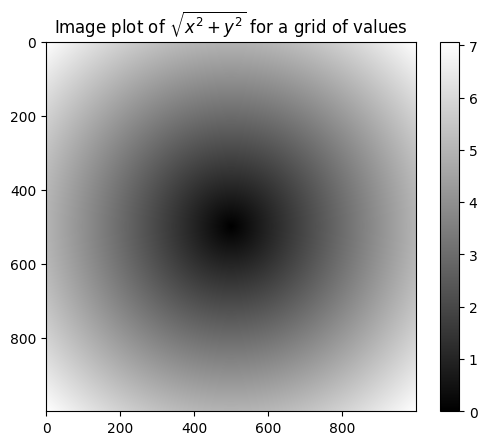

In [ ]:
## plot
import matplotlib.pyplot as plt 

plt.imshow(z, cmap=plt.cm.gray); plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

In [ ]:
# Example: pick x if cond is true and y otherwise. 
## Use zip or np.where.

xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

# use zip which means that the first element of xarr, yarr, and cond are paired together, and so on for the rest of the elements.
result = [(x if c else y) for x,y,c in zip(xarr, yarr, cond)]
print(result)

# use np.where which is faster and works in higher dimensions as well.

result = np.where(cond, xarr, yarr)
print(result)

[1.1, 2.2, 1.3, 1.4, 2.5]
[1.1 2.2 1.3 1.4 2.5]


In [22]:
# Example:  replace negatives with -2 and positives with 2. 

arr = np.random.randn(4,4)
print(arr)
print(np.where(arr>0, 2, -2)) # replace positive values with 2 and negative values with -2
print(np.where(arr>0, 2, arr)) # replace positive values with 2 and keep negative values unchanged

[[ 1.98460096 -0.0715718   0.10897173  1.64673913]
 [-0.60068824 -0.90198992  0.95125272  2.35733292]
 [ 0.91978425 -1.91023946  0.02038329 -1.61632483]
 [-1.41311601 -0.42397679 -1.14157391 -1.06809826]]
[[ 2 -2  2  2]
 [-2 -2  2  2]
 [ 2 -2  2 -2]
 [-2 -2 -2 -2]]
[[ 2.         -0.0715718   2.          2.        ]
 [-0.60068824 -0.90198992  2.          2.        ]
 [ 2.         -1.91023946  2.         -1.61632483]
 [-1.41311601 -0.42397679 -1.14157391 -1.06809826]]


In [41]:
# Example: using maths and stat methods. 

arr =np.arange(20).reshape(4,5)
print(arr)

print(f"\nThe mean using np.mean(arr) is: {np.mean(arr)}")
print(f"The sum using np.sum(arr) is: {np.sum(arr)}")

print(f"\nThe mean using arr.mean() is: {arr.mean()}") 
print(f"The sum using arr.sum() is: {arr.sum()}")

print(f"\nThe mean over the columns using arr.mean(axis=1) is: \n {arr.mean(axis=1)}")
print(f"The mean over the rows using arr.mean(axis=0) is: \n {arr.mean(axis=0)}")

print(f"\nThe cumulative sum along the rows using arr.cumsum(axis=1) is: \n {arr.cumsum(axis=1)}")



[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

The mean using np.mean(arr) is: 9.5
The sum using np.sum(arr) is: 190

The mean using arr.mean() is: 9.5
The sum using arr.sum() is: 190

The mean over the columns using arr.mean(axis=1) is: 
 [ 2.  7. 12. 17.]
The mean over the rows using arr.mean(axis=0) is: 
 [ 7.5  8.5  9.5 10.5 11.5]

The cumulative sum along the rows using arr.cumsum(axis=1) is: 
 [[ 0  1  3  6 10]
 [ 5 11 18 26 35]
 [10 21 33 46 60]
 [15 31 48 66 85]]


In [57]:
# methods for boolean arrays: any and all.
## Boolean values are 1 (True) and 0 (False). 

arr = np.random.randn(10)
print(arr)

print(f"Is any value in arr greater than 0? using `np.any(arr>0)`: {np.any(arr>0)}")
print(f"Are all values in arr greater than 0? using `np.all(arr>0)`: {np.all(arr>0)}")

print(f"How many values in arr are greater than 0? using `(arr>0).sum()`: {(arr>0).sum()}")

bools = np.array([False, False, True, False])
print(f"\nbools = {bools}")
print(f"Using `bools.any()`: {bools.any()}")
print(f"Using `bools.all()`: {bools.all()}")  
print(f"Using `bools.sum()`: {bools.sum()}")  

[ 1.52030578 -0.67140012  0.28673071  0.33281018  1.92277543  0.86413249
 -1.33811828  0.09574889 -0.35814249  1.35673719]
Is any value in arr greater than 0? using `np.any(arr>0)`: True
Are all values in arr greater than 0? using `np.all(arr>0)`: False
How many values in arr are greater than 0? using `(arr>0).sum()`: 7

bools = [False False  True False]
Using `bools.any()`: True
Using `bools.all()`: False
Using `bools.sum()`: 1


In [60]:
# sorting
arr = np.random.randn(6)
print(arr) 
print(f"Sorted arr using `arr.sort()`: {arr.sort()}") # returns a sorted copy of the array, leaving the original array unchanged
print(f"Sorted arr using `np.sort(arr)`: {np.sort(arr)}") # returns a sorted copy of the array, leaving the original array unchanged

[ 0.11619013  0.13178626 -1.57233483  1.35286919  0.48381817 -1.20161541]
Sorted arr using `arr.sort()`: None
Sorted arr using `np.sort(arr)`: [-1.57233483 -1.20161541  0.11619013  0.13178626  0.48381817  1.35286919]


In [67]:
# unique and other set logic 
## np.unique() vs. sets() in Python.

names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
print(names)
print(f"Unique names using `np.unique(names)`: {np.unique(names)}") 

## np.in1d() vs. `in` operator in Python.
values = np.array([6, 0, 0, 3, 2, 5, 6])
print(f"\nvalues = {values}")
print(f"Unique values using `np.unique(values)`: {np.unique(values)}")
print(f"Check if values are in [2, 3, 6] using `np.in1d(values, [2, 3, 6])`: \n{np.in1d(values, [2, 3, 6])}")

['Bob' 'Joe' 'Will' 'Bob' 'Will' 'Joe' 'Joe']
Unique names using `np.unique(names)`: ['Bob' 'Joe' 'Will']

values = [6 0 0 3 2 5 6]
Unique values using `np.unique(values)`: [0 2 3 5 6]
Check if values are in [2, 3, 6] using `np.in1d(values, [2, 3, 6])`: 
[ True False False  True  True False  True]
